In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jboysen/global-food-prices/wfp_market_food_prices.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(
    "/kaggle/input/datasets/jboysen/global-food-prices/wfp_market_food_prices.csv",
    encoding="latin1"
)
print(df.head())

   adm0_id    adm0_name  adm1_id   adm1_name  mkt_id  mkt_name  cm_id cm_name  \
0        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
1        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
2        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
3        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
4        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   

   cur_id cur_name  pt_id pt_name  um_id um_name  mp_month  mp_year  mp_price  \
0      87      AFN     15  Retail      5      KG         1     2014      50.0   
1      87      AFN     15  Retail      5      KG         2     2014      50.0   
2      87      AFN     15  Retail      5      KG         3     2014      50.0   
3      87      AFN     15  Retail      5      KG         4     2014      50.0   
4      87      AFN     15  Retail      5      KG         5     2014      50.0   

  mp_commoditysource  
0  

In [3]:
#to extract dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743914 entries, 0 to 743913
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   adm0_id             743914 non-null  int64  
 1   adm0_name           743914 non-null  object 
 2   adm1_id             743914 non-null  int64  
 3   adm1_name           729965 non-null  object 
 4   mkt_id              743914 non-null  int64  
 5   mkt_name            743914 non-null  object 
 6   cm_id               743914 non-null  int64  
 7   cm_name             743914 non-null  object 
 8   cur_id              743914 non-null  int64  
 9   cur_name            743914 non-null  object 
 10  pt_id               743914 non-null  int64  
 11  pt_name             743914 non-null  object 
 12  um_id               743914 non-null  int64  
 13  um_name             743914 non-null  object 
 14  mp_month            743914 non-null  int64  
 15  mp_year             743914 non-nul

In [4]:
df.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,7.439140e+05
mean,929.754832,17779.426232,885.962341,161.130914,57.325319,14.930508,10.562171,6.379772,2012.516549,4.196333e+03
std,6595.353806,81345.242217,540.492854,117.826297,23.140366,0.277872,13.160485,3.434972,3.669519,5.549296e+04
min,1.000000,0.000000,80.000000,50.000000,22.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,115.000000,1510.000000,377.000000,67.000000,30.000000,15.000000,5.000000,3.000000,2011.000000,3.000000e+01
50%,170.000000,2207.000000,912.000000,110.000000,63.000000,15.000000,5.000000,6.000000,2013.000000,1.750000e+02
75%,205.000000,21969.000000,1134.000000,233.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,5.000000e+02
max,70001.000000,900022.000000,2094.000000,490.000000,95.000000,18.000000,100.000000,12.000000,2017.000000,5.833333e+06


In [5]:
# to check null values
print(df.isnull().sum())
#to check duplicated prices in dataset
print(df.duplicated().sum())
#commodities we have
print(df["cm_name"].nunique())

adm0_id                   0
adm0_name                 0
adm1_id                   0
adm1_name             13949
mkt_id                    0
mkt_name                  0
cm_id                     0
cm_name                   0
cur_id                    0
cur_name                  0
pt_id                     0
pt_name                   0
um_id                     0
um_name                   0
mp_month                  0
mp_year                   0
mp_price                  0
mp_commoditysource        0
dtype: int64
0
321


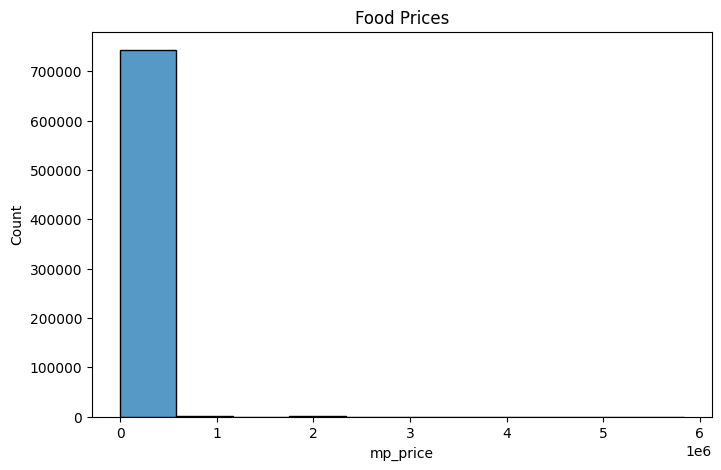

In [6]:
#now visualize the data
plt.figure(figsize=(8,5))
sns.histplot(df['mp_price'],bins=10)
plt.title("Food Prices")
plt.show()

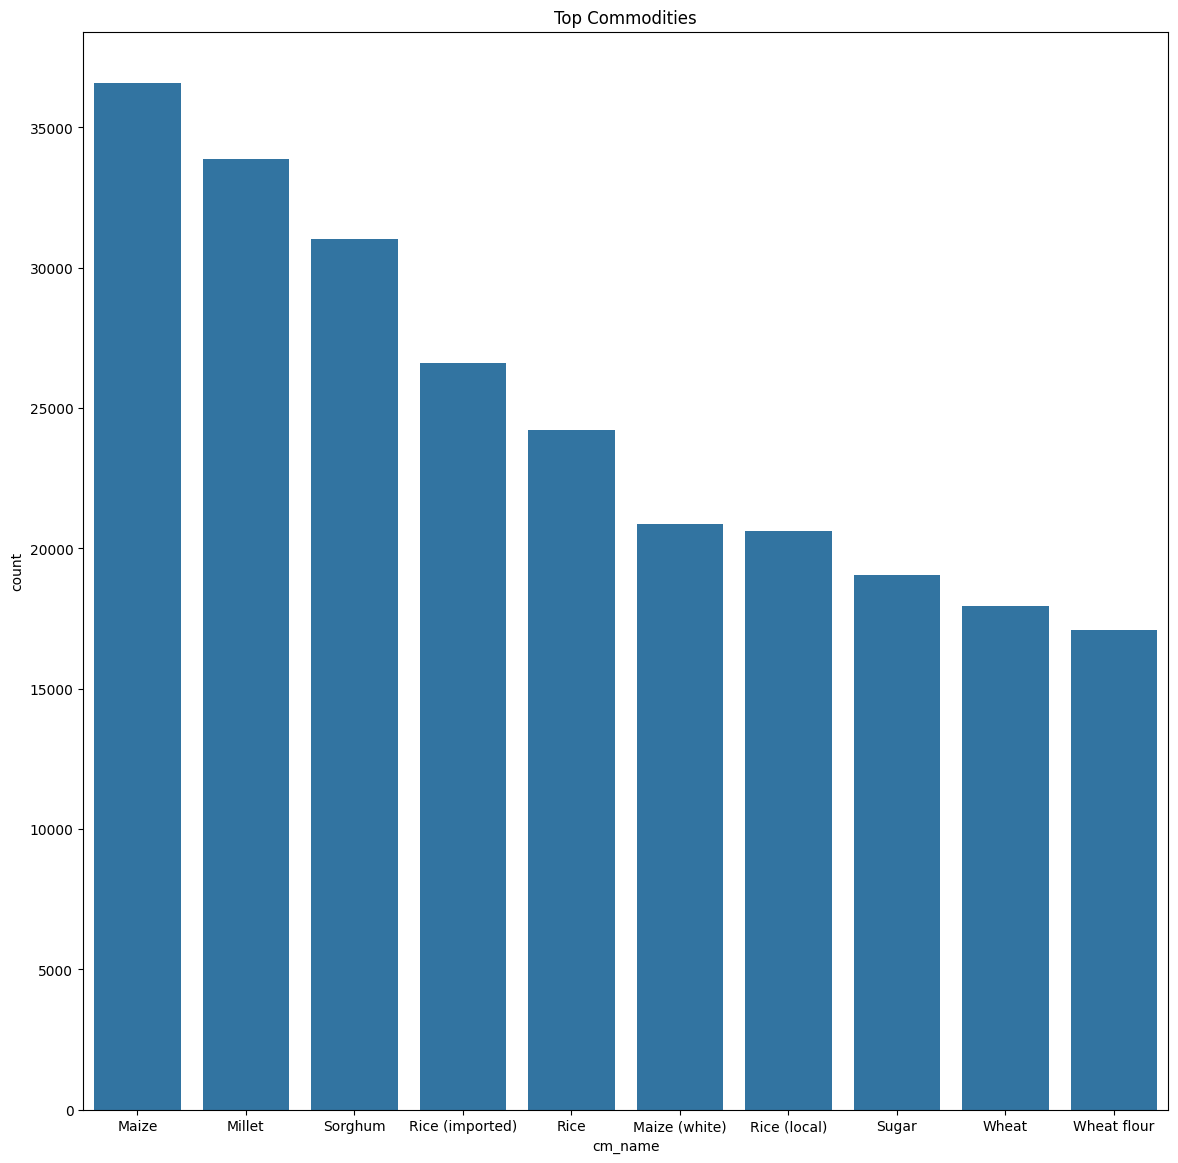

In [7]:
plt.figure(figsize=(14,14))
sns.countplot(x=df["cm_name"],order=df["cm_name"].value_counts().index[:10])
plt.title("Top Commodities")
plt.show()

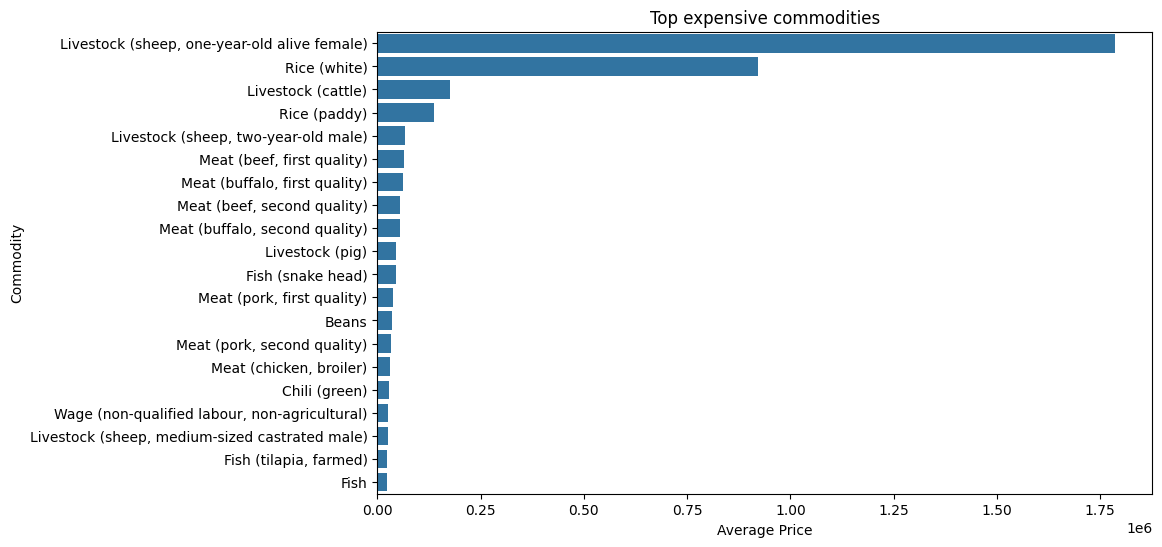

In [8]:
#to visualize top expensive commodities
top = df.groupby('cm_name')['mp_price'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top.values, y=top.index)

plt.title("Top expensive commodities")
plt.xlabel("Average Price")
plt.ylabel("Commodity")

plt.show()

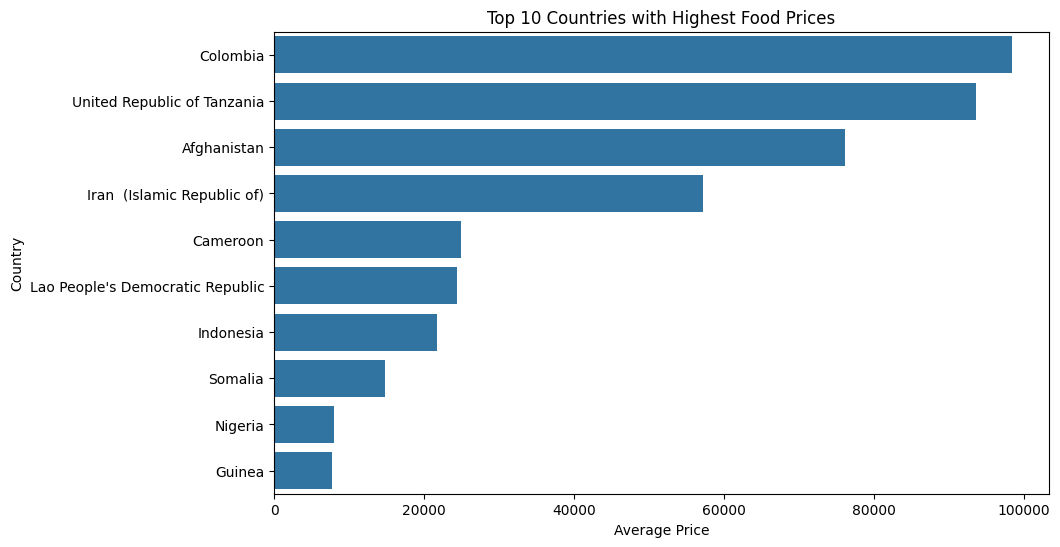

In [9]:
#countries with high prices
country_price = df.groupby('adm0_name')['mp_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=country_price.values, y=country_price.index)

plt.title("Top 10 Countries with Highest Food Prices")
plt.xlabel("Average Price")
plt.ylabel("Country")

plt.show()

In [10]:
print(df['cur_name'].unique())
print(df['cur_name'].nunique())

['AFN' 'DZD' 'AMD' 'AZN' 'BDT' 'XOF' 'BTN' 'BOB' 'BIF' 'KHR' 'XAF' 'CVE'
 'COP' 'USD' 'CDF' 'DJF' 'ETB' 'GMD' 'GEL' 'GHS' 'GTQ' 'GNF' 'HTG' 'INR'
 'IDR' 'IRR' 'IQD' 'JOD' 'KES' 'KGS' 'LAK' 'LBP' 'LSL' 'LRD' 'MGA' 'MWK'
 'MRO' 'MZN' 'MMK' 'NPR' 'NGN' 'PKR' 'PEN' 'PHP' 'RWF' 'SOS'
 'Somaliland Shilling' 'LKR' 'SZL' 'SYP' 'TJS' 'TRY' 'UGX' 'UAH' 'TZS'
 'YER' 'ZMW' 'NIS' 'SDG' 'EGP' 'SSP']
61


In [11]:
#dropping some values
df = df.drop(columns=[
    'adm0_id','adm1_id','mkt_id',
    'cm_id','cur_id','pt_id','um_id'
])

"""
The dataset contains several id columns like adm0_id, adm1_id, and mkt_id.
These columns represent numeric identifiers for categorical features that
already exist in the dataset.Since the name columns provide clearer information and the ids do not add
additional value for analysis, i removed these id columns.
"""

'\nThe dataset contains several id columns like adm0_id, adm1_id, and mkt_id.\nThese columns represent numeric identifiers for categorical features that\nalready exist in the dataset.Since the name columns provide clearer information and the ids do not add\nadditional value for analysis, i removed these id columns.\n'

In [12]:
print(df.head())
#print(df['mp_commoditysource'].unique())
#print(df['mp_commoditysource'].unique())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price mp_commoditysource  
0         1     2014      50.0                WFP  
1         2     2014      50.0                WFP  
2         3     2014      50.0                WFP  
3         4     2014      50.0                WFP  
4         5     2014      50.0                WFP  


In [13]:
df['date'] = pd.to_datetime(df['mp_year'].astype(str) + '-' + df['mp_month'].astype(str))

"""
Since month plus year represent time, i created a date feature:
This will help creating features like price last 3, 6, or 1 year
"""

'\nSince month plus year represent time, i created a date feature:\nThis will help creating features like price last 3, 6, or 1 year\n'

In [14]:
"""
also removing mp_commoditysource,
as it is not helpful for predicting prices, also too unique values like WFP,
"""
df = df.drop(columns=['mp_commoditysource'])

In [15]:
print(df.head())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price       date  
0         1     2014      50.0 2014-01-01  
1         2     2014      50.0 2014-02-01  
2         3     2014      50.0 2014-03-01  
3         4     2014      50.0 2014-04-01  
4         5     2014      50.0 2014-05-01  


In [16]:
#saving file for future phases
df.to_csv("processed_food_prices.csv", index=False)